## <span style='font-family:Palatino'>Feature Engineering.</span>

<span style='font-family:Palatino'>Before I started on the neural network I wanted to see what the data looked like visually so it could inform my choices based on how I'd help it discriminate between the two classes. In the Jupyter notebook "Feature\_enginnering\_test .ipynb" I made code which I used here, but essentially I made  a pair plot comparing the redshirts and colours against themselves: </span>

<img src="pairplot.png"  alt="Pair Plot"  width="1114px"  height="1072px"  style="object-fit:cover"/>

<span style='font-family:Palatino'>this was after a standard scaled the indexes. While I assume the redshifts are not something we should be using \(which are pretty good ways to discriminate between QSO and Galaxy\), we can see that the u\_minus\_g  histogram has the best separation between all the colour examining it closer i can kinda estimate that the point \-1 is where the QSO distrbrubbtion is greater than the galaxy distribution so I will use that as a way to directed the neural network.</span>

<span style='font-family:Palatino'>When it came to feature engineering I looked at a lot of external sources to make sure knew when to scale the data with the redshifts or not.  </span>[https://www.kaggle.com/code/rizbaltazar/classification\-of\-stars\-galaxies\-and\-quasars](https://www.kaggle.com/code/rizbaltazar/classification-of-stars-galaxies-and-quasars)  <span style='font-family:Palatino'>so I went off this, but the key difference is that before the pair plot, I got the colours as opposed to just the index since i think it gives me a more clear idea how to direct my neural network.  Essential I vectorised the "specClass"  feature using label encoder\` and renamed it "class". after that, I performed a standard scaler. </span>



### <span style='font-family:Palatino'>Neural Network:</span>

<span style='font-family:Palatino'>For my neural network i had some issues that my epoch performance produced the same value each time being 85.39%, this was weird and i felt that the data wasn't being really processed by the neural network. the issue was that the neural network labelled everything as a galaxy so 85% of the time it was right. I fixed and adjusted the output in one of my tests so that it would produce the output \(predicted classification, actual classification \) for each row of data. and it was going through the data and largely predicting them accurately with \(1,1\) and \(0,0\). Asked ChatGpt what was going wrong \(because i really had no idea what was going wrong \) it said that I was likely experiencing vanishing or exploding gradient problems i had a look at this website to get a better understanding </span>[https://www.engati.com/glossary/vanishing\-gradient\-problem](https://www.engati.com/glossary/vanishing-gradient-problem) <span style='font-family:Palatino'>because I i really didn't know I what it meant from just a description, the problem likely came from the activation function and weight. Doing further research on the He initialisation method seems to correct my weighting issue:</span>

$$
\begin{equation}
W \sim \mathcal{N}\left(0, \sqrt{\frac{2}{n_{\text{in}}}}\right)
\end{equation}
$$

<span style='font-family:Palatino'>where:</span>

$$
\begin{align*}
W & : \text{Weights of the layer} \\
\mathcal{N}(0, \sigma^2) & : \text{Normal distribution with mean 0 and variance } \sigma^2 \\
n_{\text{in}} & : \text{Number of input units in the layer}
\end{align*}
$$

<span style='font-family:Palatino'>Beyond that, i also think the neural network was susceptible to getting stuck in a local minima due to the sigmoid function.  I read that the Tanh function may be of help for the hidden layers  \(feed forrward function\) and i read this website which explained it </span>[https://medium.datadriveninvestor.com/activation\-functions\-why\-tanh\-outperforms\-logistic\-sigmoid\-3f26469ac0d1](https://medium.datadriveninvestor.com/activation-functions-why-tanh-outperforms-logistic-sigmoid-3f26469ac0d1) "<span style='font-family:Palatino'>tanh is preferred to sigmoid for faster convergence BUT again, this might change based on data. Data will also play an important role in deciding which activation function is best to choose.". I choose to keep the sigmoid function for the output layer since it's going to output something for binary classification between 0 and 1.  As for  the number of outputs since it is binary of 0,1 I thought this should be able to be done by  just 1 output with the standard sigmoid function since it should just return a binary classification.</span>



In [3]:
# loading all the packages and the neutral network module
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from Neural_Network import NeuralNetwork
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# Load and preprocess the dataset i'e "feature engineering" including vectorising the classes
k = pd.read_csv("data/SDSS_galaxies.csv")
le = LabelEncoder().fit(k['specClass'])
k["class"] = le.transform(k["specClass"])

#scaling the data using the standard data dropping both spec Class and class before 
scaler = StandardScaler()
scaled_features = scaler.fit_transform(k.drop(columns=["specClass", "class"]).values)
scaled_df = pd.DataFrame(scaled_features, columns=k.drop(columns=["specClass", "class"]).columns)

#perfoming all the colours calculations and then replacing the indexs
scaled_df['u_minus_g'] = scaled_df['u'] - scaled_df['g']
scaled_df['g_minus_r'] = scaled_df['g'] - scaled_df['r']
scaled_df['r_minus_i'] = scaled_df['r'] - scaled_df['i']
scaled_df['i_minus_z'] = scaled_df['i'] - scaled_df['z']
scaled_df.drop(columns=['u', 'g', 'r', 'i', 'z'], inplace=True)

#reintroducing the class feature. 
data = pd.concat((scaled_df, k['class']), axis=1)

X = data.drop(columns=["class"]).values
y = data["class"].values

#test size 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train_reshaped = y_train.reshape(-1, 1)
y_test_reshaped = y_test.reshape(-1, 1)

# 6 inputs 300 neurons per layer 1 out put, utulising the u_minus_g_threshold=-1 seem from the threshold
net = NeuralNetwork([6, 300, 1], u_minus_g_threshold=-1)

net.SGD(X_train, y_train, X_test, y_test, epochs=120, eta=0.001)
# After training the model
predictions_train = net.predict(X_train)

# Evaluation metrics
train_accuracy = accuracy_score(y_train, predictions_train)
train_precision = precision_score(y_train, predictions_train)
train_recall = recall_score(y_train, predictions_train)
train_f1 = f1_score(y_train, predictions_train)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Training Precision: {train_precision:.4f}")
print(f"Training Recall: {train_recall:.4f}")
print(f"Training F1 Score: {train_f1:.4f}")


Epoch #0
Performance: 9861 / 10000


Epoch #10
Performance: 9888 / 10000


Epoch #20
Performance: 9893 / 10000


Epoch #30
Performance: 9895 / 10000


Epoch #40
Performance: 9895 / 10000


...

Epoch #80
Performance: 9898 / 10000


Epoch #90
Performance: 9898 / 10000


Epoch #100
Performance: 9899 / 10000


Epoch #110
Performance: 9901 / 10000


Training Accuracy: 0.9920
Training Precision: 0.9877
Training Recall: 0.9557
Training F1 Score: 0.9715


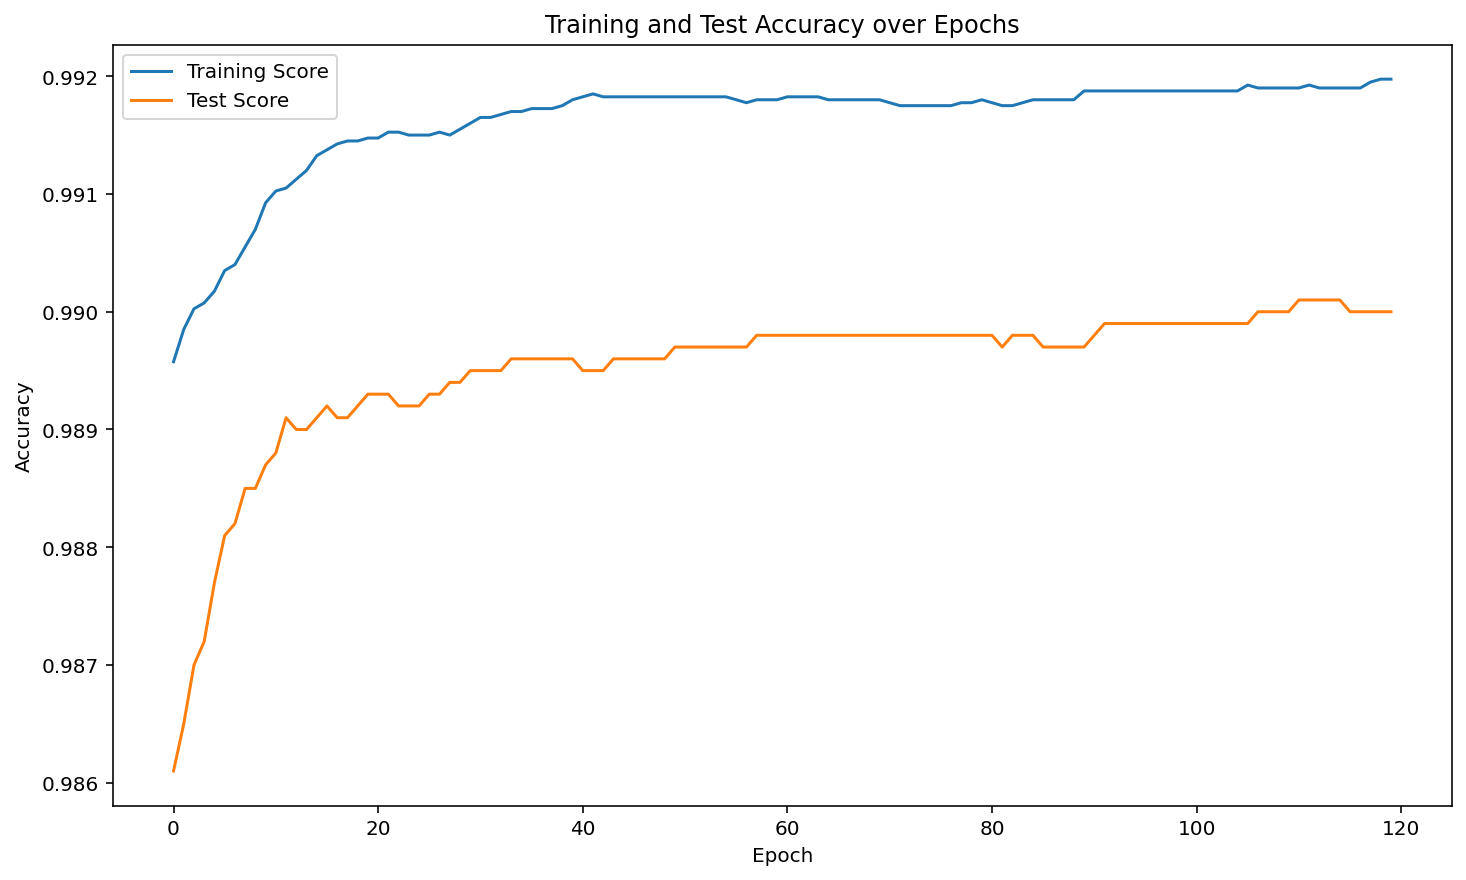

In [4]:
#plot the neural network accurary for each epoch
plt.plot(net.train_scores, label='Training Score')
plt.plot(net.test_scores, label='Test Score')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracy over Epochs')
plt.show()

Best parameters found:  {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


Evaluation Metrics:
Accuracy: 0.9944
Precision: 0.9901
Recall: 0.9874
F1 Score: 0.9887
Confusion Matrix:
[[8516   23]
 [  33 1428]]


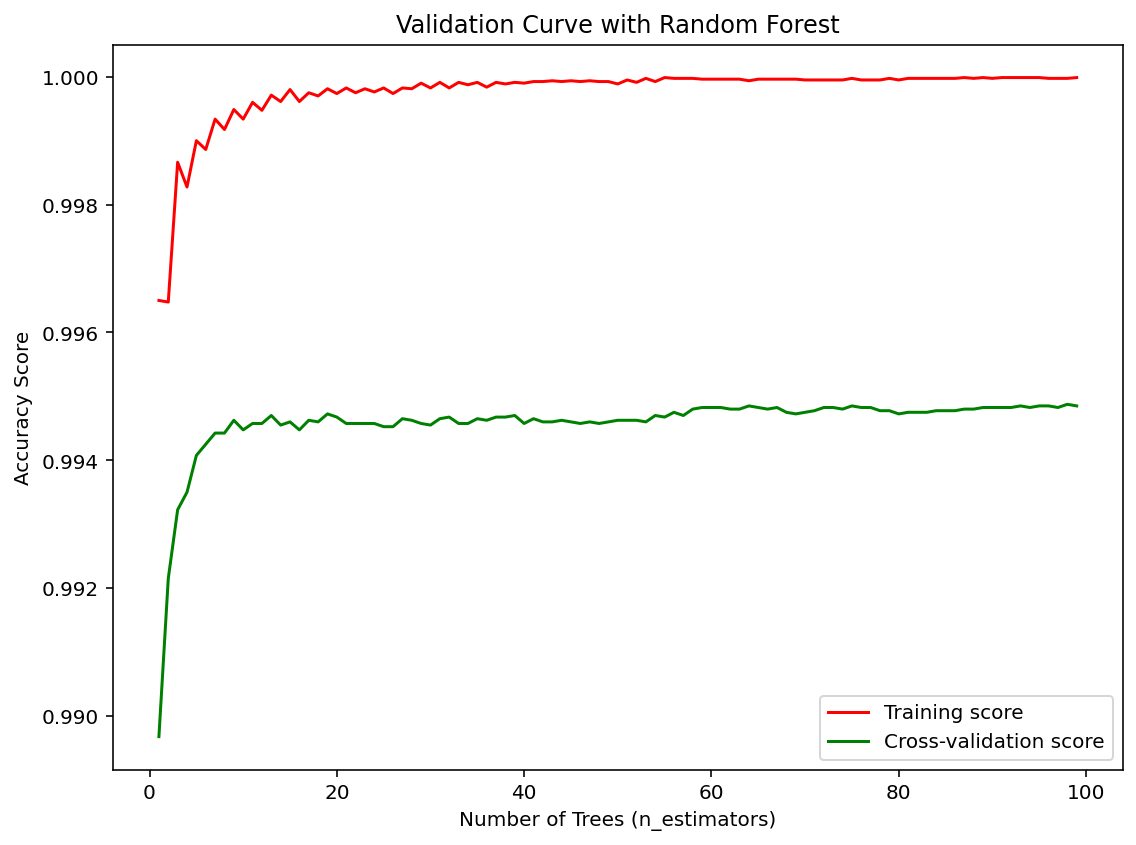

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV, validation_curve

#Random Forest classifier
rf_classifier = RandomForestClassifier(random_state=42)

# The parameter grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 50],
    'min_samples_split': [2, 5]
}

# Grid search
grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=3, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Best parameters from the grid search
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# Training  the classifier with best parameters
best_rf_classifier = grid_search.best_estimator_
best_rf_classifier.fit(X_train, y_train)

# Prediction from the test set
y_pred = best_rf_classifier.predict(X_test)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
conf_matrix = confusion_matrix(y_test, y_pred)

print("Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

# Validation curve
param_range = np.arange(1, 100) 
train_scores, test_scores = validation_curve(
    RandomForestClassifier(random_state=42),
    X_train, y_train,
    param_name='n_estimators',
    param_range=param_range,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

# Mean for training and test scores
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# Plot validation curve 
plt.figure(figsize=(8, 6))
plt.plot(param_range, train_mean, label="Training score", color="r")
plt.plot(param_range, test_mean, label="Cross-validation score", color="g")

plt.title("Validation Curve with Random Forest")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy Score")
plt.tight_layout()
plt.legend(loc="best")
plt.show()

In [6]:
from prettytable import PrettyTable
table = PrettyTable()

# Define the columns
table.field_names = ["Metric", "Neural Network", "Random Forest"]

# Add rows for each metric
table.add_row(["Accuracy", f"{train_accuracy:.4f}", f"{accuracy:.4f}"])
table.add_row(["Precision", f"{train_precision:.4f}", f"{precision:.4f}"])
table.add_row(["Recall", f"{train_recall:.4f}", f"{recall:.4f}"])
table.add_row(["F1 Score", f"{train_f1:.4f}", f"{f1:.4f}"])

# Print the table
print(table)

+-----------+----------------+---------------+
|   Metric  | Neural Network | Random Forest |
+-----------+----------------+---------------+
|  Accuracy |     0.9920     |     0.9944    |
| Precision |     0.9877     |     0.9901    |
|   Recall  |     0.9557     |     0.9874    |
|  F1 Score |     0.9715     |     0.9887    |
+-----------+----------------+---------------+


<span style='font-family:Palatino'>From the pretty table, we can see while the neural network gets close to the random forest it still has a clean sweep. the accuracy is pretty good as well as the precision, the recall is a bit wayward so it's not as good at identifying positive instances. and the f1 score is good. Overall the neural network performs at an adequate level. 300 neurons might be an issue since that likely will induce some overfitting but it performs a bit better than single digits and the effects aren't too extreme since it is basically all in the 97th\-100th percentile. Perhasps using Relu might imporve the performance as that is much more unlikely to not be effected by the vanishing and exploding points.</span>
